In [1]:
import os
import sys

PROJECT_ROOT = r"C:\sourcecode\Nhom_10_Big_Data"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Current working directory:", os.getcwd())
print("Project root added:", PROJECT_ROOT in sys.path)

Current working directory: C:\sourcecode\Nhom_10_Big_Data\src\ml
Project root added: True


In [2]:
from src.config.spark_session import get_spark
from src.config.hdfs_config import SUPERSTORE_DATASET
from src.config.schema import SUPERSTORE_SCHEMA

spark = get_spark("G10_Customer_Repurchase_90D_Classification")
spark.sparkContext.setLogLevel("WARN")

print("HDFS path:", SUPERSTORE_DATASET)

HDFS path: hdfs://master:9000/bigdata/superstore/input/G10_dataset.csv


In [3]:
df = (
    spark.read
    .option("header", True)
    .schema(SUPERSTORE_SCHEMA)
    .csv(SUPERSTORE_DATASET)
)

print("Số dòng:", df.count())
print("Số cột:", len(df.columns))

df.printSchema()

Số dòng: 110000
Số cột: 24
root
 |-- Category: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- Customer_Name: string (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Market: string (nullable = true)
 |-- Order_Date: date (nullable = true)
 |-- Order_ID: string (nullable = true)
 |-- Order_Priority: string (nullable = true)
 |-- Product_ID: string (nullable = true)
 |-- Product_Name: string (nullable = true)
 |-- Profit: double (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Ship_Date: date (nullable = true)
 |-- Ship_Mode: string (nullable = true)
 |-- Shipping_Cost: double (nullable = true)
 |-- State: string (nullable = true)
 |-- Sub_Category: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- weeknum: integer (nullable = true)

In [4]:
df.select(
    "Order_ID",
    "Customer_ID",
    "Order_Date",
    "Ship_Date",
    "Sales",
    "Quantity",
    "Discount",
    "Shipping_Cost",
    "Segment",
    "Market",
    "Region",
    "Ship_Mode",
    "Order_Priority",
    "Category",
    "Sub_Category"
).show(10, truncate=False)

+--------------+-----------+----------+----------+-----+--------+--------+-------------+--------+------+------+--------------+--------------+---------------+------------+
|Order_ID      |Customer_ID|Order_Date|Ship_Date |Sales|Quantity|Discount|Shipping_Cost|Segment |Market|Region|Ship_Mode     |Order_Priority|Category       |Sub_Category|
+--------------+-----------+----------+----------+-----+--------+--------+-------------+--------+------+------+--------------+--------------+---------------+------------+
|CA-2011-130813|LS-172304  |2011-01-07|2011-01-09|19.0 |3       |0.0     |4.37         |Consumer|US    |West  |Second Class  |High          |Office Supplies|Paper       |
|CA-2011-148614|MV-174854  |2011-01-21|2011-01-26|19.0 |2       |0.0     |0.94         |Consumer|US    |West  |Standard Class|Medium        |Office Supplies|Paper       |
|CA-2011-118962|CS-121304  |2011-08-05|2011-08-09|21.0 |3       |0.0     |1.81         |Consumer|US    |West  |Standard Class|Medium        |Offi

In [5]:
from pyspark.sql.functions import (
    col,
    countDistinct,
    sum as spark_sum,
    avg,
    max as spark_max,
    min as spark_min,
    first as spark_first,
    datediff,
    year,
    month
)

order_df = (
    df
    .filter(
        col("Order_ID").isNotNull() &
        col("Customer_ID").isNotNull() &
        col("Order_Date").isNotNull()
    )
    .groupBy("Order_ID", "Customer_ID")
    .agg(
        spark_min("Order_Date").alias("Order_Date"),
        spark_max("Ship_Date").alias("Ship_Date"),

        spark_first("Customer_Name", True).alias("Customer_Name"),
        spark_first("Segment", True).alias("Segment"),
        spark_first("Market", True).alias("Market"),
        spark_first("Region", True).alias("Region"),
        spark_first("Ship_Mode", True).alias("Ship_Mode"),
        spark_first("Order_Priority", True).alias("Order_Priority"),

        spark_first("Category", True).alias("main_category"),
        spark_first("Sub_Category", True).alias("main_sub_category"),

        spark_sum("Sales").alias("order_sales"),
        spark_sum("Quantity").alias("total_items"),
        avg("Discount").alias("order_avg_discount"),
        spark_sum("Shipping_Cost").alias("order_shipping_cost"),

        countDistinct("Category").alias("num_categories"),
        countDistinct("Sub_Category").alias("num_sub_categories")
    )
    .withColumn("ship_days", datediff(col("Ship_Date"), col("Order_Date")))
    .withColumn("order_year", year(col("Order_Date")))
    .withColumn("order_month", month(col("Order_Date")))
)

print("Số dòng sau khi gom về cấp đơn hàng:", order_df.count())
print("Số khách hàng:", order_df.select("Customer_ID").distinct().count())

order_df.select(
    "Order_ID",
    "Customer_ID",
    "Order_Date",
    "Ship_Date",
    "Segment",
    "Market",
    "Ship_Mode",
    "main_category",
    "order_sales",
    "total_items",
    "order_avg_discount",
    "order_shipping_cost",
    "num_categories",
    "num_sub_categories",
    "ship_days"
).show(10, truncate=False)

Số dòng sau khi gom về cấp đơn hàng: 55127
Số khách hàng: 4873
+------------+-----------+----------+----------+-----------+------+--------------+---------------+-----------+-----------+------------------+-------------------+--------------+------------------+---------+
|Order_ID    |Customer_ID|Order_Date|Ship_Date |Segment    |Market|Ship_Mode     |main_category  |order_sales|total_items|order_avg_discount|order_shipping_cost|num_categories|num_sub_categories|ship_days|
+------------+-----------+----------+----------+-----------+------+--------------+---------------+-----------+-----------+------------------+-------------------+--------------+------------------+---------+
|AE-2014-4120|JD-57902   |2014-03-07|2014-03-11|Consumer   |EMEA  |Standard Class|Office Supplies|6.0        |2          |0.7               |0.49               |1             |1                 |4        |
|AG-2011-1440|DB-32101   |2011-12-15|2011-12-20|Consumer   |Africa|Standard Class|Office Supplies|59.0       |2  

In [6]:
from pyspark.sql import Window
from pyspark.sql.functions import (
    col,
    lag,
    lead,
    row_number,
    coalesce,
    lit,
    when,
    datediff,
    sum as spark_sum,
    avg,
    min as spark_min
)

customer_window = (
    Window
    .partitionBy("Customer_ID")
    .orderBy(col("Order_Date"), col("Order_ID"))
)

history_window = (
    Window
    .partitionBy("Customer_ID")
    .orderBy(col("Order_Date"), col("Order_ID"))
    .rowsBetween(Window.unboundedPreceding, -1)
)

lifetime_window = (
    Window
    .partitionBy("Customer_ID")
    .orderBy(col("Order_Date"), col("Order_ID"))
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)
)

order_features = (
    order_df
    .withColumn("previous_order_date", lag("Order_Date").over(customer_window))
    .withColumn("next_order_date", lead("Order_Date").over(customer_window))
    .withColumn("order_sequence", row_number().over(customer_window))
    .withColumn("previous_order_count", col("order_sequence") - 1)

    .withColumn(
        "days_since_previous_order",
        coalesce(
            datediff(col("Order_Date"), col("previous_order_date")),
            lit(999)
        )
    )

    .withColumn(
        "previous_total_sales",
        coalesce(
            spark_sum("order_sales").over(history_window),
            lit(0.0)
        )
    )

    .withColumn(
        "previous_avg_order_value",
        when(
            col("previous_order_count") > 0,
            col("previous_total_sales") / col("previous_order_count")
        ).otherwise(lit(0.0))
    )

    .withColumn(
        "previous_avg_discount",
        coalesce(
            avg("order_avg_discount").over(history_window),
            lit(0.0)
        )
    )

    .withColumn(
        "previous_avg_shipping_cost",
        coalesce(
            avg("order_shipping_cost").over(history_window),
            lit(0.0)
        )
    )

    .withColumn(
        "first_order_date",
        spark_min("Order_Date").over(lifetime_window)
    )

    .withColumn(
        "customer_lifetime_days",
        datediff(col("Order_Date"), col("first_order_date"))
    )
)

order_features.select(
    "Customer_ID",
    "Order_ID",
    "Order_Date",
    "previous_order_date",
    "next_order_date",
    "previous_order_count",
    "days_since_previous_order",
    "previous_total_sales",
    "previous_avg_order_value",
    "previous_avg_discount",
    "previous_avg_shipping_cost",
    "customer_lifetime_days"
).show(20, truncate=False)

+-----------+---------------+----------+-------------------+---------------+--------------------+-------------------------+--------------------+------------------------+---------------------+--------------------------+----------------------+
|Customer_ID|Order_ID       |Order_Date|previous_order_date|next_order_date|previous_order_count|days_since_previous_order|previous_total_sales|previous_avg_order_value|previous_avg_discount|previous_avg_shipping_cost|customer_lifetime_days|
+-----------+---------------+----------+-------------------+---------------+--------------------+-------------------------+--------------------+------------------------+---------------------+--------------------------+----------------------+
|AA-103151  |ID-2011-40953  |2011-07-04|NULL               |2013-12-14     |0                   |999                      |0.0                 |0.0                     |0.0                  |0.0                       |0                     |
|AA-103151  |GEN-006505     |201

In [7]:
from datetime import timedelta

REPURCHASE_DAYS = 90

max_order_date = order_features.agg(
    spark_max("Order_Date").alias("max_order_date")
).collect()[0]["max_order_date"]

cutoff_date = max_order_date - timedelta(days=REPURCHASE_DAYS)

print("Ngày đơn hàng cuối cùng trong dataset:", max_order_date)
print("Chỉ giữ các đơn hàng có Order_Date <=", cutoff_date)

Ngày đơn hàng cuối cùng trong dataset: 2014-12-31
Chỉ giữ các đơn hàng có Order_Date <= 2014-10-02


In [8]:
model_base = (
    order_features
    .filter(col("Order_Date") <= lit(cutoff_date))
    .withColumn(
        "days_to_next_order",
        datediff(col("next_order_date"), col("Order_Date"))
    )
    .withColumn(
        "label",
        when(
            col("next_order_date").isNotNull() &
            (col("days_to_next_order") <= REPURCHASE_DAYS),
            lit(1.0)
        ).otherwise(lit(0.0))
    )
)

print("Số dòng dataset mô hình:", model_base.count())

model_base.select(
    "Customer_ID",
    "Order_ID",
    "Order_Date",
    "next_order_date",
    "days_to_next_order",
    "order_sales",
    "total_items",
    "order_avg_discount",
    "order_shipping_cost",
    "previous_order_count",
    "days_since_previous_order",
    "previous_total_sales",
    "previous_avg_order_value",
    "label"
).show(20, truncate=False)

Số dòng dataset mô hình: 48797
+-----------+--------------+----------+---------------+------------------+------------------+-----------+------------------+-------------------+--------------------+-------------------------+--------------------+------------------------+-----+
|Customer_ID|Order_ID      |Order_Date|next_order_date|days_to_next_order|order_sales       |total_items|order_avg_discount|order_shipping_cost|previous_order_count|days_since_previous_order|previous_total_sales|previous_avg_order_value|label|
+-----------+--------------+----------+---------------+------------------+------------------+-----------+------------------+-------------------+--------------------+-------------------------+--------------------+------------------------+-----+
|AA-103753  |MX-2012-108028|2012-04-03|2012-11-07     |218               |21.0              |3          |0.0               |1.126              |0                   |999                      |0.0                 |0.0                     |

Tiền xử lý xong

In [9]:
from pyspark.sql.functions import round as spark_round

total_rows = model_base.count()

label_distribution = (
    model_base
    .groupBy("label")
    .count()
    .withColumn("ratio_pct", spark_round(col("count") * 100 / total_rows, 2))
    .orderBy("label")
)

label_distribution.show()

+-----+-----+---------+
|label|count|ratio_pct|
+-----+-----+---------+
|  0.0|14609|    29.94|
|  1.0|34188|    70.06|
+-----+-----+---------+



In [12]:
numeric_features = [
    "order_sales",
    "total_items",
    "order_avg_discount",
    "order_shipping_cost",
    "num_categories",
    "num_sub_categories",
    "ship_days",
    "order_month",

    "previous_order_count",
    "days_since_previous_order",
    "previous_total_sales",
    "previous_avg_order_value",
    "previous_avg_discount",
    "previous_avg_shipping_cost",
    "customer_lifetime_days"
]

categorical_features = [
    "Segment",
    "Market",
    "Region",
    "Ship_Mode",
    "Order_Priority",
    "main_category",
    "main_sub_category"
]

print("Numeric features:")
for c in numeric_features:
    print("-", c)

print("\nCategorical features:")
for c in categorical_features:
    print("-", c)

Numeric features:
- order_sales
- total_items
- order_avg_discount
- order_shipping_cost
- num_categories
- num_sub_categories
- ship_days
- order_month
- previous_order_count
- days_since_previous_order
- previous_total_sales
- previous_avg_order_value
- previous_avg_discount
- previous_avg_shipping_cost
- customer_lifetime_days

Categorical features:
- Segment
- Market
- Region
- Ship_Mode
- Order_Priority
- main_category
- main_sub_category


In [13]:
from pyspark.sql.functions import col, lit, when, isnan, coalesce, sum as spark_sum

# Kiểm tra biến phân loại bị null
categorical_null_exprs = [
    spark_sum(
        when(col(c).isNull(), 1).otherwise(0)
    ).alias(c)
    for c in categorical_features
]

print("Kiểm tra Null ở các biến phân loại:")
model_base.select(categorical_null_exprs).show()

Kiểm tra Null ở các biến phân loại:
+-------+------+------+---------+--------------+-------------+-----------------+
|Segment|Market|Region|Ship_Mode|Order_Priority|main_category|main_sub_category|
+-------+------+------+---------+--------------+-------------+-----------------+
|      0|     0|     0|        0|             0|            0|                0|
+-------+------+------+---------+--------------+-------------+-----------------+



In [14]:
# Kiểm tra biến số bị Null / NaN / Infinity
numeric_invalid_exprs = []

for c in numeric_features:
    numeric_invalid_exprs.append(
        spark_sum(
            when(
                col(c).isNull()
                | isnan(col(c).cast("double"))
                | (col(c).cast("double") == float("inf"))
                | (col(c).cast("double") == float("-inf")),
                1
            ).otherwise(0)
        ).alias(c)
    )

print("Kiểm tra Null / NaN / Infinity ở các biến số:")
model_base.select(numeric_invalid_exprs).show()

Kiểm tra Null / NaN / Infinity ở các biến số:
+-----------+-----------+------------------+-------------------+--------------+------------------+---------+-----------+--------------------+-------------------------+--------------------+------------------------+---------------------+--------------------------+----------------------+
|order_sales|total_items|order_avg_discount|order_shipping_cost|num_categories|num_sub_categories|ship_days|order_month|previous_order_count|days_since_previous_order|previous_total_sales|previous_avg_order_value|previous_avg_discount|previous_avg_shipping_cost|customer_lifetime_days|
+-----------+-----------+------------------+-------------------+--------------+------------------+---------+-----------+--------------------+-------------------------+--------------------+------------------------+---------------------+--------------------------+----------------------+
|        133|        146|                 0|                146|             0|                 

In [15]:
model_clean = model_base

# Thay null ở biến phân loại bằng Unknown
for c in categorical_features:
    model_clean = model_clean.withColumn(
        c,
        when(col(c).isNull(), lit("Unknown")).otherwise(col(c))
    )

# Thay Null / NaN / Infinity ở biến số bằng 0.0
for c in numeric_features:
    model_clean = model_clean.withColumn(
        c,
        when(
            col(c).isNull()
            | isnan(col(c).cast("double"))
            | (col(c).cast("double") == float("inf"))
            | (col(c).cast("double") == float("-inf")),
            lit(0.0)
        ).otherwise(col(c).cast("double"))
    )

print("Số dòng trước xử lý:", model_base.count())
print("Số dòng sau xử lý:", model_clean.count())

Số dòng trước xử lý: 48797
Số dòng sau xử lý: 48797


In [16]:
numeric_invalid_exprs_after = []

for c in numeric_features:
    numeric_invalid_exprs_after.append(
        spark_sum(
            when(
                col(c).isNull()
                | isnan(col(c).cast("double"))
                | (col(c).cast("double") == float("inf"))
                | (col(c).cast("double") == float("-inf")),
                1
            ).otherwise(0)
        ).alias(c)
    )

print("Kiểm tra lại biến số sau xử lý:")
model_clean.select(numeric_invalid_exprs_after).show()

Kiểm tra lại biến số sau xử lý:
+-----------+-----------+------------------+-------------------+--------------+------------------+---------+-----------+--------------------+-------------------------+--------------------+------------------------+---------------------+--------------------------+----------------------+
|order_sales|total_items|order_avg_discount|order_shipping_cost|num_categories|num_sub_categories|ship_days|order_month|previous_order_count|days_since_previous_order|previous_total_sales|previous_avg_order_value|previous_avg_discount|previous_avg_shipping_cost|customer_lifetime_days|
+-----------+-----------+------------------+-------------------+--------------+------------------+---------+-----------+--------------------+-------------------------+--------------------+------------------------+---------------------+--------------------------+----------------------+
|          0|          0|                 0|                  0|             0|                 0|        0|  

In [17]:
print("Dataset sau tiền xử lý cho mô hình ML:")

model_clean.select(
    "Customer_ID",
    "Order_ID",
    "Order_Date",
    "next_order_date",
    "days_to_next_order",
    "order_sales",
    "total_items",
    "order_avg_discount",
    "order_shipping_cost",
    "previous_order_count",
    "days_since_previous_order",
    "previous_total_sales",
    "previous_avg_order_value",
    "previous_avg_discount",
    "previous_avg_shipping_cost",
    "Segment",
    "Market",
    "Region",
    "Ship_Mode",
    "Order_Priority",
    "main_category",
    "main_sub_category",
    "label"
).show(20, truncate=False)

Dataset sau tiền xử lý cho mô hình ML:
+-----------+--------------+----------+---------------+------------------+------------------+-----------+------------------+-------------------+--------------------+-------------------------+--------------------+------------------------+---------------------+--------------------------+--------+------+-------+--------------+--------------+---------------+-----------------+-----+
|Customer_ID|Order_ID      |Order_Date|next_order_date|days_to_next_order|order_sales       |total_items|order_avg_discount|order_shipping_cost|previous_order_count|days_since_previous_order|previous_total_sales|previous_avg_order_value|previous_avg_discount|previous_avg_shipping_cost|Segment |Market|Region |Ship_Mode     |Order_Priority|main_category  |main_sub_category|label|
+-----------+--------------+----------+---------------+------------------+------------------+-----------+------------------+-------------------+--------------------+-------------------------+--------

In [18]:
from pyspark.sql.functions import col, lit, to_date

TRAIN_CUTOFF_DATE = "2014-01-01"

train_raw = model_clean.filter(
    col("Order_Date") < to_date(lit(TRAIN_CUTOFF_DATE))
)

test_raw = model_clean.filter(
    (col("Order_Date") >= to_date(lit(TRAIN_CUTOFF_DATE))) &
    (col("Order_Date") <= lit(cutoff_date))
)

train_count = train_raw.count()
test_count = test_raw.count()

print("Train rows:", train_count)
print("Test rows:", test_count)

print("Phân phối nhãn trong train:")
train_raw.groupBy("label").count().orderBy("label").show()

print("Phân phối nhãn trong test:")
test_raw.groupBy("label").count().orderBy("label").show()

Train rows: 36268
Test rows: 12529
Phân phối nhãn trong train:
+-----+-----+
|label|count|
+-----+-----+
|  0.0|11319|
|  1.0|24949|
+-----+-----+

Phân phối nhãn trong test:
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 3290|
|  1.0| 9239|
+-----+-----+



In [19]:
from pyspark.sql.functions import when

train_count = train_raw.count()

count_0 = train_raw.filter(col("label") == 0).count()
count_1 = train_raw.filter(col("label") == 1).count()

weight_0 = train_count / (2 * count_0) if count_0 > 0 else 0
weight_1 = train_count / (2 * count_1) if count_1 > 0 else 0

print("count_0:", count_0)
print("count_1:", count_1)
print("weight_0:", weight_0)
print("weight_1:", weight_1)

train_df = train_raw.withColumn(
    "class_weight",
    when(col("label") == 0, lit(weight_0)).otherwise(lit(weight_1))
)

test_df = test_raw.withColumn(
    "class_weight",
    when(col("label") == 0, lit(weight_0)).otherwise(lit(weight_1))
)

train_df.select(
    "Order_ID",
    "Customer_ID",
    "Order_Date",
    "label",
    "class_weight"
).show(10, truncate=False)

count_0: 11319
count_1: 24949
weight_0: 1.602084989840092
weight_1: 0.7268427592288268
+---------------+-----------+----------+-----+------------------+
|Order_ID       |Customer_ID|Order_Date|label|class_weight      |
+---------------+-----------+----------+-----+------------------+
|ID-2011-40953  |AA-103151  |2011-07-04|0.0  |1.602084989840092 |
|GEN-006505     |AA-103151  |2013-12-14|1.0  |0.7268427592288268|
|GEN-001674     |AA-103151  |2013-12-23|1.0  |0.7268427592288268|
|GEN-027579     |AA-103151  |2013-12-24|1.0  |0.7268427592288268|
|IN-2013-58152  |AA-103151  |2013-12-31|1.0  |0.7268427592288268|
|GEN-019107     |AA-103152  |2012-05-07|1.0  |0.7268427592288268|
|ES-2012-2960821|AA-103152  |2012-05-16|0.0  |1.602084989840092 |
|GEN-018126     |AA-103152  |2013-07-30|1.0  |0.7268427592288268|
|ES-2013-5491146|AA-103152  |2013-08-07|1.0  |0.7268427592288268|
|ES-2013-4677050|AA-103152  |2013-09-19|1.0  |0.7268427592288268|
+---------------+-----------+----------+-----+---------

In [20]:
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)

from pyspark.ml import Pipeline

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in categorical_features
]

encoders = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_ohe",
        handleInvalid="keep"
    )
    for c in categorical_features
]

numeric_assembler = VectorAssembler(
    inputCols=numeric_features,
    outputCol="numeric_vector",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="numeric_vector",
    outputCol="scaled_numeric_vector",
    withStd=True,
    withMean=False
)

final_feature_inputs = ["scaled_numeric_vector"] + [
    f"{c}_ohe" for c in categorical_features
]

final_assembler = VectorAssembler(
    inputCols=final_feature_inputs,
    outputCol="features",
    handleInvalid="keep"
)

print("Final feature inputs:")
for c in final_feature_inputs:
    print("-", c)

Final feature inputs:
- scaled_numeric_vector
- Segment_ohe
- Market_ohe
- Region_ohe
- Ship_Mode_ohe
- Order_Priority_ohe
- main_category_ohe
- main_sub_category_ohe


In [21]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    weightCol="class_weight",
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    numTrees=100,
    maxDepth=8,
    seed=10
)

pipeline = Pipeline(
    stages=indexers + encoders + [
        numeric_assembler,
        scaler,
        final_assembler,
        rf
    ]
)

model = pipeline.fit(train_df)

predictions = model.transform(test_df)

predictions.select(
    "Order_ID",
    "Customer_ID",
    "Order_Date",
    "label",
    "prediction",
    "probability"
).show(20, truncate=False)

+---------------+-----------+----------+-----+----------+----------------------------------------+
|Order_ID       |Customer_ID|Order_Date|label|prediction|probability                             |
+---------------+-----------+----------+-----+----------+----------------------------------------+
|GEN-018988     |AA-104804  |2014-04-02|1.0  |1.0       |[0.4611196063209729,0.5388803936790272] |
|CA-2014-114412 |AA-104804  |2014-04-16|1.0  |0.0       |[0.512909429987816,0.48709057001218403] |
|GEN-018491     |AA-104804  |2014-05-14|0.0  |0.0       |[0.5134916642577215,0.48650833574227836]|
|BO-2014-9240   |AA-3152    |2014-06-05|0.0  |1.0       |[0.48598562399216844,0.5140143760078315]|
|GEN-009364     |AA-3753    |2014-03-25|1.0  |1.0       |[0.49795022515496107,0.5020497748450389]|
|TU-2014-2650   |AA-3753    |2014-04-22|1.0  |0.0       |[0.5424162705879886,0.45758372941201136]|
|GEN-021952     |AA-3753    |2014-05-13|0.0  |0.0       |[0.5413464798499728,0.45865352015002714]|
|IN-2014-1

In [22]:
confusion_matrix = (
    predictions
    .groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
)

confusion_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 2240|
|  0.0|       1.0| 1050|
|  1.0|       0.0| 5094|
|  1.0|       1.0| 4145|
+-----+----------+-----+



In [23]:
tp = predictions.filter((col("label") == 1) & (col("prediction") == 1)).count()
tn = predictions.filter((col("label") == 0) & (col("prediction") == 0)).count()
fp = predictions.filter((col("label") == 0) & (col("prediction") == 1)).count()
fn = predictions.filter((col("label") == 1) & (col("prediction") == 0)).count()

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

TP: 4155
TN: 2240
FP: 1051
FN: 5084


In [24]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
import pandas as pd

eval_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

eval_weighted_precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

eval_weighted_recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

spark_accuracy = eval_acc.evaluate(predictions)
spark_f1 = eval_f1.evaluate(predictions)
spark_weighted_precision = eval_weighted_precision.evaluate(predictions)
spark_weighted_recall = eval_weighted_recall.evaluate(predictions)

roc_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(predictions)

pr_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
).evaluate(predictions)

total = tp + tn + fp + fn

precision_positive = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_positive = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

f1_positive = (
    2 * precision_positive * recall_positive / (precision_positive + recall_positive)
    if (precision_positive + recall_positive) > 0
    else 0
)

false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

metrics_data = [
    ("Accuracy", spark_accuracy),
    ("Weighted Precision", spark_weighted_precision),
    ("Weighted Recall", spark_weighted_recall),
    ("Weighted F1-score", spark_f1),
    ("Positive Precision", precision_positive),
    ("Positive Recall / Sensitivity", recall_positive),
    ("Positive F1-score", f1_positive),
    ("Specificity", specificity),
    ("False Positive Rate", false_positive_rate),
    ("False Negative Rate", false_negative_rate),
    ("ROC-AUC", roc_auc),
    ("PR-AUC", pr_auc)
]

metrics_pd = pd.DataFrame(metrics_data, columns=["Metric", "Value"])
metrics_pd["Value"] = metrics_pd["Value"].round(4)

metrics_pd

,Metric,Value
0,Accuracy,0.5102
1,Weighted Precision,0.6686
2,Weighted Recall,0.5097
3,Weighted F1-score,0.5350
4,Positive Precision,0.7981
5,Positive Recall / Sensitivity,0.4497
6,Positive F1-score,0.5753
7,Specificity,0.6806
8,False Positive Rate,0.3194
9,False Negative Rate,0.5503


In [25]:
from pyspark.ml.functions import vector_to_array

pred_with_score = (
    predictions
    .withColumn("probability_array", vector_to_array(col("probability")))
    .withColumn("return_probability", col("probability_array")[1])
    .drop("probability_array")
)

pred_with_score.select(
    "Order_ID",
    "Customer_ID",
    "Order_Date",
    "label",
    "prediction",
    "return_probability"
).show(20, truncate=False)

+---------------+-----------+----------+-----+----------+-------------------+
|Order_ID       |Customer_ID|Order_Date|label|prediction|return_probability |
+---------------+-----------+----------+-----+----------+-------------------+
|GEN-018988     |AA-104804  |2014-04-02|1.0  |1.0       |0.5388803936790272 |
|CA-2014-114412 |AA-104804  |2014-04-16|1.0  |0.0       |0.48709057001218403|
|GEN-018491     |AA-104804  |2014-05-14|0.0  |0.0       |0.48650833574227836|
|BO-2014-9240   |AA-3152    |2014-06-05|0.0  |1.0       |0.5140143760078315 |
|GEN-009364     |AA-3753    |2014-03-25|1.0  |1.0       |0.5020497748450389 |
|TU-2014-2650   |AA-3753    |2014-04-22|1.0  |0.0       |0.45758372941201136|
|GEN-021952     |AA-3753    |2014-05-13|0.0  |0.0       |0.45865352015002714|
|IN-2014-13184  |AB-100151  |2014-02-10|0.0  |1.0       |0.5413414945287225 |
|ID-2014-48583  |AB-100151  |2014-06-23|1.0  |1.0       |0.551369485860787  |
|IN-2014-63710  |AB-100151  |2014-09-09|0.0  |1.0       |0.56244

In [26]:
pred_with_score.select("return_probability").summary(
    "count", "min", "25%", "50%", "75%", "max"
).show()

+-------+-------------------+
|summary| return_probability|
+-------+-------------------+
|  count|              12529|
|    min|0.36875441830110167|
|    25%| 0.4853164393585325|
|    50%|0.49569530773744835|
|    75%| 0.5364447050954788|
|    max| 0.6145344425858011|
+-------+-------------------+



In [27]:
quantiles = pred_with_score.approxQuantile(
    "return_probability",
    [0.33, 0.66],
    0.01
)

low_threshold = quantiles[0]
high_threshold = quantiles[1]

print("Low threshold:", low_threshold)
print("High threshold:", high_threshold)

Low threshold: 0.4889173117963241
High threshold: 0.507558265664847


In [28]:
customer_priority = pred_with_score.withColumn(
    "return_group",
    when(col("return_probability") >= lit(high_threshold), "High Return Probability")
    .when(col("return_probability") >= lit(low_threshold), "Medium Return Probability")
    .otherwise("Low Return Probability")
)

customer_priority.groupBy("return_group").count().show()

+--------------------+-----+
|        return_group|count|
+--------------------+-----+
|Medium Return Pro...| 4126|
|High Return Proba...| 4360|
|Low Return Probab...| 4043|
+--------------------+-----+



In [29]:
top_return_orders = (
    customer_priority
    .select(
        "Order_ID",
        "Customer_ID",
        "Customer_Name",
        "Order_Date",
        "Segment",
        "Market",
        "Region",
        "Ship_Mode",
        "order_sales",
        "total_items",
        "previous_order_count",
        "days_since_previous_order",
        "label",
        "prediction",
        "return_probability",
        "return_group"
    )
    .orderBy(col("return_probability").desc())
)

top_return_orders.show(20, truncate=False)

+---------------+-----------+-----------------+----------+-----------+------+---------+--------------+------------------+-----------+--------------------+-------------------------+-----+----------+------------------+-----------------------+
|Order_ID       |Customer_ID|Customer_Name    |Order_Date|Segment    |Market|Region   |Ship_Mode     |order_sales       |total_items|previous_order_count|days_since_previous_order|label|prediction|return_probability|return_group           |
+---------------+-----------+-----------------+----------+-----------+------+---------+--------------+------------------+-----------+--------------------+-------------------------+-----+----------+------------------+-----------------------+
|MX-2014-107216 |FG-142603  |Frank Gastineau  |2014-09-05|Home Office|LATAM |Caribbean|Standard Class|27.0              |3.0        |0.0                 |999.0                    |1.0  |1.0       |0.6145344425858011|High Return Probability|
|GEN-012593     |KM-162253  |Kalyca 

In [30]:
low_return_orders = (
    customer_priority
    .select(
        "Order_ID",
        "Customer_ID",
        "Customer_Name",
        "Order_Date",
        "Segment",
        "Market",
        "Region",
        "Ship_Mode",
        "order_sales",
        "total_items",
        "previous_order_count",
        "days_since_previous_order",
        "label",
        "prediction",
        "return_probability",
        "return_group"
    )
    .orderBy(col("return_probability").asc())
)

low_return_orders.show(20, truncate=False)

+------------+-----------+-----------------+----------+-----------+------+------+--------------+-----------------+-----------+--------------------+-------------------------+-----+----------+-------------------+----------------------+
|Order_ID    |Customer_ID|Customer_Name    |Order_Date|Segment    |Market|Region|Ship_Mode     |order_sales      |total_items|previous_order_count|days_since_previous_order|label|prediction|return_probability |return_group          |
+------------+-----------+-----------------+----------+-----------+------+------+--------------+-----------------+-----------+--------------------+-------------------------+-----+----------+-------------------+----------------------+
|CA-2014-4440|MK-81602   |Mike Kennedy     |2014-08-14|Consumer   |Canada|Canada|Standard Class|80.0             |3.0        |1.0                 |26.0                     |1.0  |0.0       |0.36875441830110167|Low Return Probability|
|GEN-000087  |JH-61802   |Justin Hirsh     |2014-09-22|Consumer 

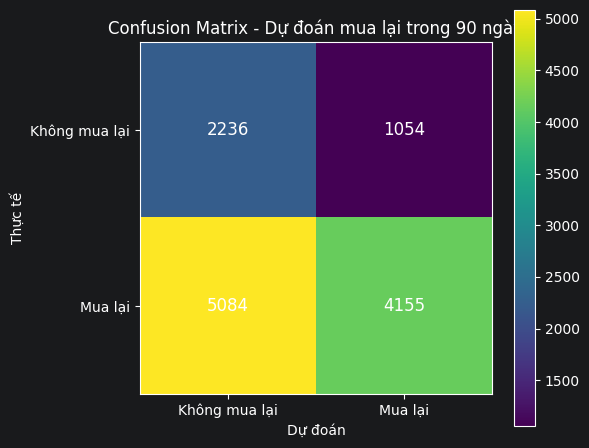

In [31]:
import matplotlib.pyplot as plt
import numpy as np

cm_pd = confusion_matrix.toPandas()

cm = np.zeros((2, 2), dtype=int)

for _, row in cm_pd.iterrows():
    actual = int(row["label"])
    predicted = int(row["prediction"])
    cm[actual, predicted] = int(row["count"])

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Không mua lại", "Mua lại"])
ax.set_yticklabels(["Không mua lại", "Mua lại"])

ax.set_xlabel("Dự đoán")
ax.set_ylabel("Thực tế")
ax.set_title("Confusion Matrix - Dự đoán mua lại trong 90 ngày")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig("../../images/ml/fig_repurchase_90d_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

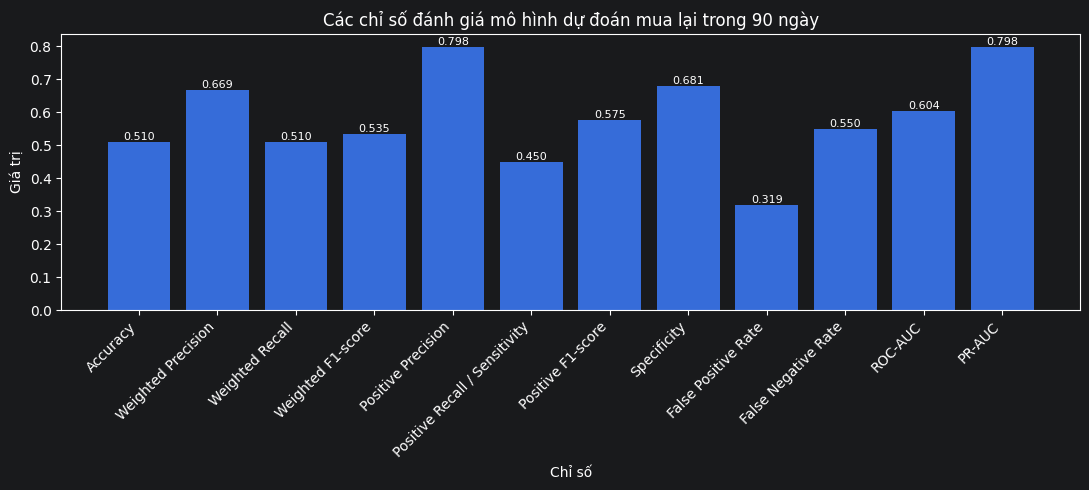

In [32]:
plt.figure(figsize=(11, 5))

plt.bar(metrics_pd["Metric"], metrics_pd["Value"])

plt.title("Các chỉ số đánh giá mô hình dự đoán mua lại trong 90 ngày")
plt.xlabel("Chỉ số")
plt.ylabel("Giá trị")
plt.xticks(rotation=45, ha="right")

for i, value in enumerate(metrics_pd["Value"]):
    plt.text(
        i,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.savefig("../../images/ml/fig_repurchase_90d_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

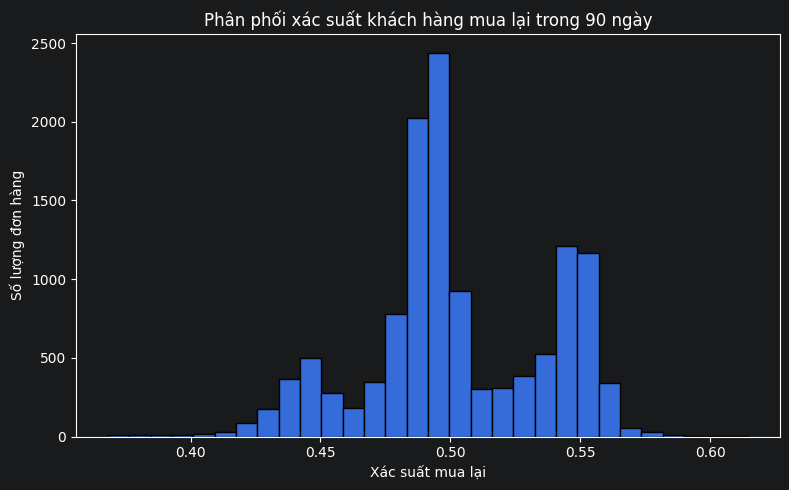

In [33]:
score_pd = (
    pred_with_score
    .select("return_probability")
    .toPandas()
)

plt.figure(figsize=(8, 5))

plt.hist(
    score_pd["return_probability"],
    bins=30,
    edgecolor="black"
)

plt.title("Phân phối xác suất khách hàng mua lại trong 90 ngày")
plt.xlabel("Xác suất mua lại")
plt.ylabel("Số lượng đơn hàng")

plt.tight_layout()
plt.savefig("../../images/ml/fig_repurchase_probability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

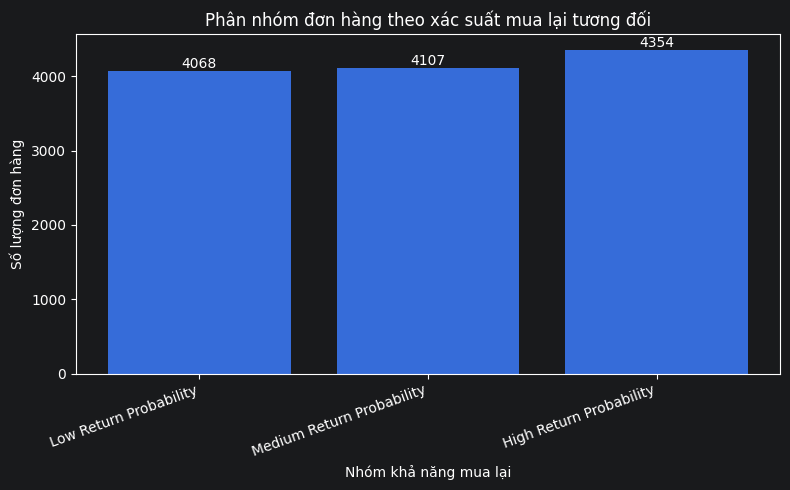

In [34]:
priority_pd = (
    customer_priority
    .groupBy("return_group")
    .count()
    .toPandas()
)

group_order = [
    "Low Return Probability",
    "Medium Return Probability",
    "High Return Probability"
]

priority_pd["return_group"] = priority_pd["return_group"].astype(str)
priority_pd = priority_pd.set_index("return_group").reindex(group_order).reset_index()
priority_pd["count"] = priority_pd["count"].fillna(0)

plt.figure(figsize=(8, 5))

plt.bar(
    priority_pd["return_group"],
    priority_pd["count"]
)

plt.title("Phân nhóm đơn hàng theo xác suất mua lại tương đối")
plt.xlabel("Nhóm khả năng mua lại")
plt.ylabel("Số lượng đơn hàng")
plt.xticks(rotation=20, ha="right")

for i, value in enumerate(priority_pd["count"]):
    plt.text(
        i,
        value,
        int(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("../../images/ml/fig_repurchase_return_groups_quantile.png", dpi=300, bbox_inches="tight")
plt.show()